### 多项式特征解决非线性问题

In [69]:
import numpy as np
import matplotlib.pyplot as plt

In [70]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.2, random_state=0)  # 生成双月形二分类数据集，加入的随机噪声大小

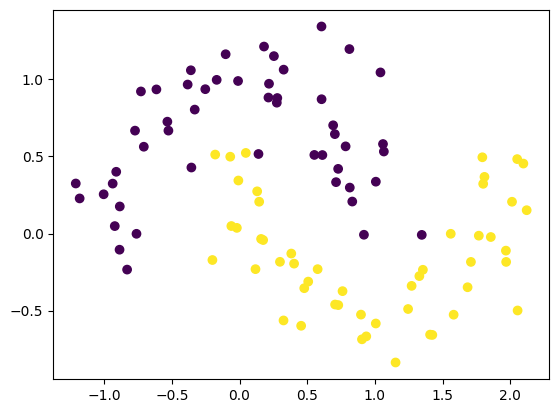

In [71]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [72]:
from sklearn.svm import LinearSVC
lscv = LinearSVC()
lscv.fit(X, y);

In [73]:
def decision_boundary_plot(X, y, clf):
    axis_x1_min, axis_x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    axis_x2_min, axis_x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    x1, x2 = np.meshgrid(
        np.arange(axis_x1_min, axis_x1_max, 0.01),
        np.arange(axis_x2_min, axis_x2_max, 0.01))

    z = clf.predict(np.c_[x1.ravel(), x2.ravel()])
    z = z.reshape(x1.shape)

    from matplotlib.colors import ListedColormap
    custom_cmap = ListedColormap(['#F5B9EF', '#BBFFBB', '#F9F9CB'])

    plt.contourf(x1, x2, z, cmap=custom_cmap)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.show()

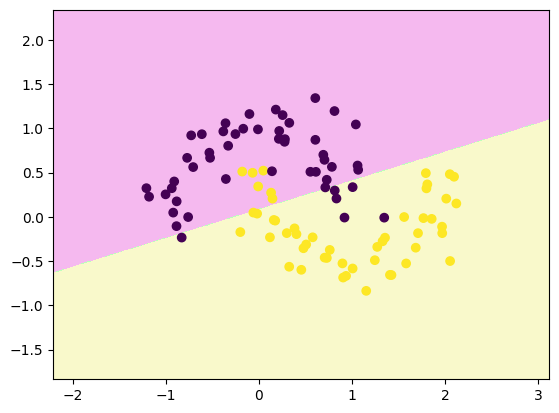

In [74]:
decision_boundary_plot(X, y, lscv)

In [75]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [76]:
poly_svc = Pipeline([  # 创建流水线：依次进行多项式特征扩展、标准化和线性 SVM 分类
    ("poly", PolynomialFeatures(degree=3)),  # 将原始特征扩展为 3 次多项式特征，使线性 SVM 能够处理非线性分类问题
    ("std_scaler", StandardScaler()),  # 对扩展后的特征进行标准化，使各特征具有相近的尺度，提高 SVM 的训练效果
    ("linearSVC", LinearSVC())  # 使用线性支持向量机进行分类
])

In [77]:
poly_svc.fit(X, y);

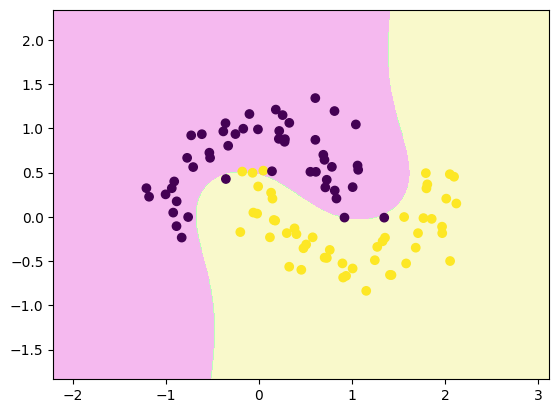

In [78]:
decision_boundary_plot(X, y, poly_svc)

### 多项式核函数解决非线性问题

In [79]:
from sklearn.svm import SVC

In [80]:
poly_svc = Pipeline([
    ("std_scaler", StandardScaler()),
    ("polySVC", SVC(kernel="poly", degree=3))
])

In [81]:
poly_svc.fit(X, y);

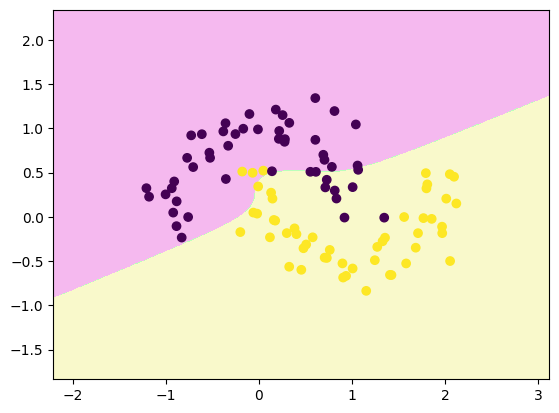

In [82]:
decision_boundary_plot(X, y, poly_svc)

### 高斯核函数解决非线性问题

In [83]:
rbf_svc = Pipeline([
    ("std_scaler", StandardScaler()),
    ("rbfSVC", SVC(kernel="rbf", gamma=1))
])

In [84]:
rbf_svc.fit(X, y);

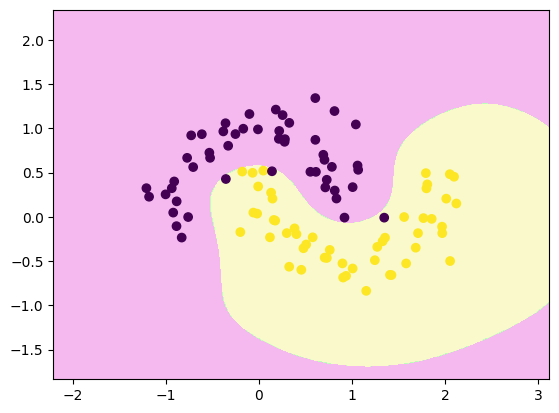

In [85]:
decision_boundary_plot(X, y, rbf_svc)